In [1]:
%matplotlib inline
import matplotlib
matplotlib.rc('image', interpolation='nearest', origin='lower', cmap='viridis')
import matplotlib.pyplot as plt
import numpy as np
import stpsf
stpsf.setup_logging()
from stpsf import roman

STPSF log messages of level INFO and above will be shown.
STPSF log outputs will be directed to the screen.


# JWST NIRCam

[  stpsf] NIRCam aperture name updated to NRCA1_FULL
[  poppy] No source spectrum supplied, therefore defaulting to 5700 K blackbody
[  poppy] Computing wavelength weights using synthetic photometry for F210M...
[  poppy] PSF calc using fov_arcsec = 5.000000, oversample = 4, number of wavelengths = 9
[  stpsf] Creating optical system model:
[  poppy] Initialized OpticalSystem: JWST+NIRCam
[  poppy] JWST Entrance Pupil: Loaded amplitude transmission from stpsf-data-source/jwst_pupil_RevW_npix1024.fits.gz
[  poppy] JWST Entrance Pupil: Loaded OPD from stpsf-data-source/JWST_OTE_OPD_cycle1_example_2022-07-30.fits
[  stpsf] Loading field dependent model parameters from stpsf-data-source/NIRCam/OPD/field_dep_table_nircam.fits
[  stpsf] Calculating field-dependent OTE OPD at v2 = 2.010 arcmin, v3 = -8.792 arcmin
[  poppy] Added pupil plane: JWST Entrance Pupil
[  poppy] Added coordinate inversion plane: OTE exit pupil
[  poppy] Added pupil plane: NIRCamSWA internal WFE at V2V3=(2.01,-8.79)',

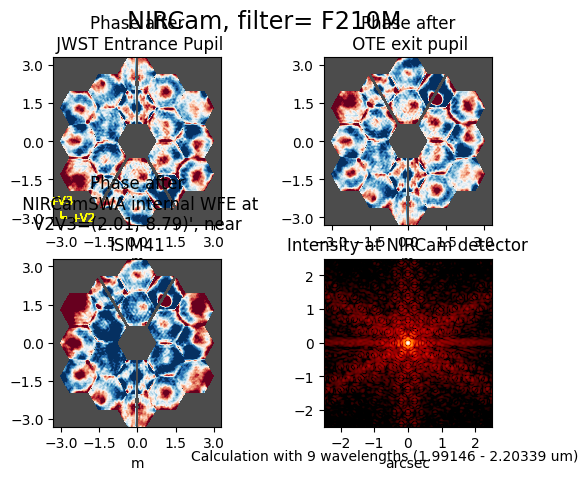

In [2]:
nc = stpsf.NIRCam()
nc.filter = 'F210M'
psf, interm = nc.calc_psf(display=True, return_intermediates=True)

# Roman WFI

[  stpsf] Using pupil mask 'F062' and detector 'WFI01'.
[  stpsf] Using pupil mask 'F087' and detector 'WFI01'.
[  poppy] No source spectrum supplied, therefore defaulting to 5700 K blackbody
[  poppy] Computing wavelength weights using synthetic photometry for F087...
[  stpsf] Using pupil mask 'F087' and detector 'WFI01'.
[  poppy] PSF calc using fov_arcsec = 5.000000, oversample = 4, number of wavelengths = 10
[  stpsf] Creating optical system model:
[  poppy] Initialized OpticalSystem: Roman+WFI
[  poppy] Roman Entrance Pupil: Loaded amplitude transmission from stpsf-data-source/WFI/pupils/RST_WIM_Filter_F087_WFI01.fits.gz
[  poppy] Roman Entrance Pupil: Loaded OPD from stpsf-data-source/upscaled_HST_OPD.fits
[  poppy] Added pupil plane: Roman Entrance Pupil
[  poppy] Added coordinate inversion plane: OTE exit pupil
[  poppy] Added pupil plane: Field Dependent Aberration (WFI01)
[  poppy] Added detector with pixelscale=0.1078577405 and oversampling=4: WFI detector
[  poppy] Calcula

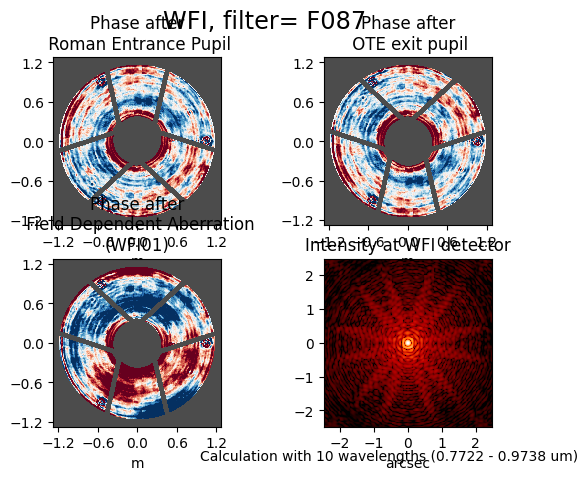

In [3]:
wfi = roman.WFI()
wfi.filter = 'F087'
wpsf, winterm = wfi.calc_psf(display=True, return_intermediates=True)

# Make the figure

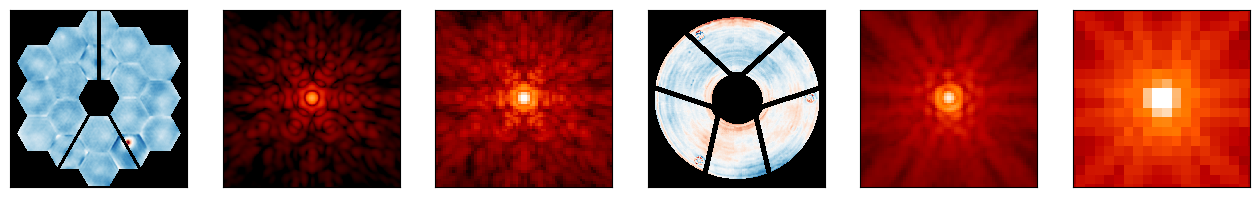

In [4]:
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(16, 4))

for ax in axes:
    ax.patch.set_facecolor('black')

crop_arcsec = 2.0

# JWST NIRCam
phasemap = interm[0].phase.copy()
phasemap[interm[0].intensity == 0.0] = np.nan
axes[0].imshow(phasemap, cmap='RdBu_r')
stpsf.display_psf(psf, ext='OVERSAMP', colorbar=False, ax=axes[1], imagecrop=crop_arcsec)
stpsf.display_psf(psf, ext='DET_SAMP', colorbar=False, ax=axes[2], imagecrop=crop_arcsec)

# Roman WFI
wphasemap = winterm[2].phase.copy()
wphasemap[winterm[2].intensity == 0.0] = np.nan
axes[3].imshow(wphasemap, cmap='RdBu_r')
stpsf.display_psf(wpsf, ext='OVERSAMP', colorbar=False, ax=axes[4], imagecrop=crop_arcsec)
stpsf.display_psf(wpsf, ext='DET_SAMP', colorbar=False, ax=axes[5], imagecrop=crop_arcsec)


for ax in axes:
    ax.set_title('')
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_xticks([])
    ax.set_yticks([])

plt.savefig('./readme_fig.png', bbox_inches='tight')